# 🧪 BigMart Sales — Streamlit App Testing
**Notebook 03 | Validate the saved model & test prediction pipeline before running the Streamlit app**

Steps:
1. Load saved model artifacts
2. Inspect model components
3. Test prediction pipeline on sample inputs
4. Batch prediction test
5. Sanity checks & edge cases

In [1]:
import pickle
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## 1️⃣  Load Saved Model Artifacts

In [2]:
with open('../models/sales_model.pkl', 'rb') as f:
    artifacts = pickle.load(f)

model          = artifacts['model']
scaler         = artifacts['scaler']
label_encoders = artifacts['label_encoders']
feature_cols   = artifacts['feature_cols']
cat_cols       = artifacts['cat_cols']

print('Model type:     ', type(model).__name__)
print('Feature count:  ', len(feature_cols))
print('Features:       ', feature_cols)
print('Cat columns:    ', cat_cols)

Model type:      XGBRegressor
Feature count:   12
Features:        ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age', 'Item_Category', 'Price_per_Weight', 'Visibility_MeanRatio']
Cat columns:     ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category']


## 2️⃣  Preprocessing Function (mirrors app.py logic)

In [3]:
def preprocess_input(input_dict: dict) -> pd.DataFrame:
    """
    Transforms a raw user-input dict into a model-ready DataFrame.
    Mirrors the preprocessing done in app.py.
    """
    df = pd.DataFrame([input_dict])

    # 1. Fix fat content
    fat_map = {'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'}
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace(fat_map)

    # 2. Derived features
    df['Outlet_Age']          = 2013 - df['Outlet_Establishment_Year']
    df['Item_Category']       = df['Item_Identifier'].str[:2].map(
        {'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'}
    ).fillna('Food')
    df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'
    df['Price_per_Weight']    = df['Item_MRP'] / df['Item_Weight']
    df['Visibility_MeanRatio'] = 1.0   # neutral when we don't have outlet-level mean

    # 3. Drop unused cols
    df = df.drop(columns=['Item_Identifier', 'Outlet_Identifier',
                           'Outlet_Establishment_Year'], errors='ignore')

    # 4. Label encode
    for col in cat_cols:
        if col in df.columns:
            le = label_encoders[col]
            df[col] = df[col].astype(str)
            # Handle unseen labels gracefully
            df[col] = df[col].apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

    # 5. Align to training features
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0

    return df[feature_cols]


def predict_sales(input_dict: dict) -> float:
    X = preprocess_input(input_dict)
    return float(model.predict(X)[0])

print('Functions defined ✅')

Functions defined ✅


## 3️⃣  Sample Predictions

In [4]:
# Sample 1 — Typical grocery item
sample1 = {
    'Item_Identifier':          'FD_X01',
    'Item_Weight':               9.3,
    'Item_Fat_Content':         'Low Fat',
    'Item_Visibility':           0.016,
    'Item_Type':                'Snack Foods',
    'Item_MRP':                  107.86,
    'Outlet_Identifier':        'OUT049',
    'Outlet_Establishment_Year': 1999,
    'Outlet_Size':              'Medium',
    'Outlet_Location_Type':     'Tier 1',
    'Outlet_Type':              'Supermarket Type1',
}

pred1 = predict_sales(sample1)
print(f'Sample 1 Predicted Sales: ₹ {pred1:,.2f}')

Sample 1 Predicted Sales: ₹ 652.47


In [5]:
# Sample 2 — High MRP luxury item in Tier 3
sample2 = {
    'Item_Identifier':          'FD_X02',
    'Item_Weight':               15.0,
    'Item_Fat_Content':         'Regular',
    'Item_Visibility':           0.025,
    'Item_Type':                'Seafood',
    'Item_MRP':                  266.0,
    'Outlet_Identifier':        'OUT027',
    'Outlet_Establishment_Year': 1985,
    'Outlet_Size':              'High',
    'Outlet_Location_Type':     'Tier 3',
    'Outlet_Type':              'Supermarket Type3',
}

pred2 = predict_sales(sample2)
print(f'Sample 2 Predicted Sales: ₹ {pred2:,.2f}')

Sample 2 Predicted Sales: ₹ 1,803.78


In [6]:
# Sample 3 — Grocery store (expected low sales)
sample3 = {
    'Item_Identifier':          'NC_X03',
    'Item_Weight':               5.0,
    'Item_Fat_Content':         'Low Fat',
    'Item_Visibility':           0.010,
    'Item_Type':                'Household',
    'Item_MRP':                  50.0,
    'Outlet_Identifier':        'OUT010',
    'Outlet_Establishment_Year': 1998,
    'Outlet_Size':              'Small',
    'Outlet_Location_Type':     'Tier 1',
    'Outlet_Type':              'Grocery Store',
}

pred3 = predict_sales(sample3)
print(f'Sample 3 Predicted Sales (Grocery Store): ₹ {pred3:,.2f}')

Sample 3 Predicted Sales (Grocery Store): ₹ 378.12


## 4️⃣  Batch Prediction Test

In [7]:
test_df = pd.read_csv('../data/Train.csv').head(100)

preds = []
for _, row in test_df.iterrows():
    try:
        p = predict_sales(row.to_dict())
        preds.append(p)
    except Exception as e:
        preds.append(None)
        print(f'Error: {e}')

test_df['Predicted_Sales'] = preds
print(f'Success rate: {test_df["Predicted_Sales"].notna().mean()*100:.1f}%')
test_df[['Item_Identifier', 'Item_MRP', 'Outlet_Type', 'Item_Outlet_Sales', 'Predicted_Sales']].head(10)

Success rate: 100.0%


,Item_Identifier,Item_MRP,Outlet_Type,Item_Outlet_Sales,Predicted_Sales
0,FDA15,249.8092,Supermarket Type1,3735.1380,1873.677612
1,DRC01,48.2692,Supermarket Type2,443.4228,304.143829
2,FDN15,141.6180,Supermarket Type1,2097.2700,821.898621
3,FDX07,182.0950,Grocery Store,732.3800,1315.093506
4,NCD19,53.8614,Supermarket Type1,994.7052,388.564697
5,FDP36,51.4008,Supermarket Type2,556.6088,338.326721
6,FDO10,57.6588,Supermarket Type1,343.5528,394.445587
7,FDP10,107.7622,Supermarket Type3,4022.7636,1248.797119
8,FDH17,96.9726,Supermarket Type1,1076.5986,639.471619
9,FDU28,187.8214,Supermarket Type1,4710.5350,1268.645020


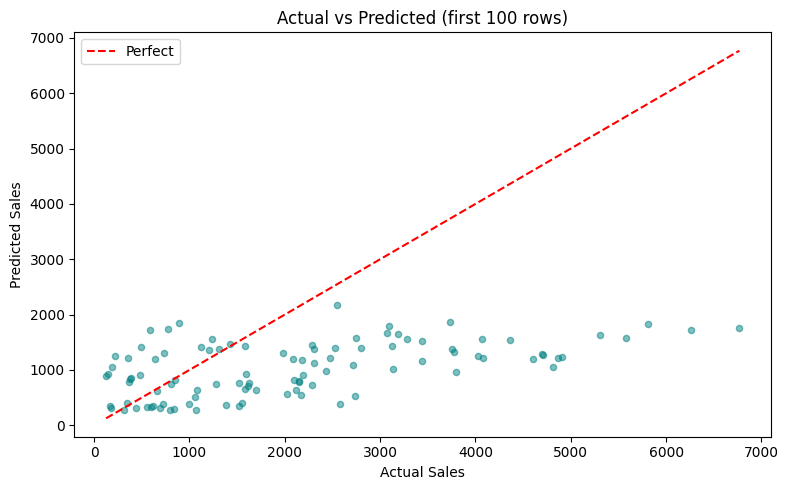

In [8]:
import matplotlib.pyplot as plt

subset = test_df.dropna(subset=['Predicted_Sales'])
plt.figure(figsize=(8, 5))
plt.scatter(subset['Item_Outlet_Sales'], subset['Predicted_Sales'],
            alpha=0.5, color='teal', s=20)
mn = min(subset['Item_Outlet_Sales'].min(), subset['Predicted_Sales'].min())
mx = max(subset['Item_Outlet_Sales'].max(), subset['Predicted_Sales'].max())
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted (first 100 rows)')
plt.legend()
plt.tight_layout()
plt.show()

## 5️⃣  ✅ App Readiness Checklist

In [9]:
checks = {
    'Model loaded':          model is not None,
    'Feature columns set':   len(feature_cols) > 0,
    'Label encoders exist':  len(label_encoders) > 0,
    'Sample pred 1 > 0':     pred1 > 0,
    'Sample pred 2 > pred3': pred2 > pred3,   # high MRP supermarket > grocery
    'Batch success 100%':    test_df['Predicted_Sales'].notna().all(),
}

for check, status in checks.items():
    icon = '✅' if status else '❌'
    print(f'{icon}  {check}')

if all(checks.values()):
    print('\n🚀 Model is ready — run: streamlit run app.py')
else:
    print('\n⚠️  Fix failing checks before launching the app.')

✅  Model loaded
✅  Feature columns set
✅  Label encoders exist
✅  Sample pred 1 > 0
✅  Sample pred 2 > pred3
✅  Batch success 100%

🚀 Model is ready — run: streamlit run app.py
